In [1]:
# Imports and Setup

from glass_dynamics.core.logger import logger

from glass_dynamics.data.processor import filter_and_fit_dataset
from glass_dynamics.data.composition import gen_atomic_df
from glass_dynamics.data.splitting import split_by_cassar_indices, split_by_random_seed

from glass_dynamics.features.generator import generate_all_features, generate_cassar_35_features
from glass_dynamics.features.correlation import select_features_from_clusters
from glass_dynamics.features.vif import calculate_vif, calculate_ridge_vif, iterative_vif_selection, fast_iterative_vif_selection

from glass_dynamics.analysis.performance import compute_alpha_performance_metrics
from glass_dynamics.analysis.traces import compute_weight_traces
from glass_dynamics.analysis.feature_importance import extract_importance
from glass_dynamics.analysis.evolution import extract_top_features_evolution
from glass_dynamics.analysis.extrapolation import generate_extrapolation_metrics
from glass_dynamics.analysis.myega_bootstrap import generate_bootstrap_predictions
from glass_dynamics.analysis.elastic_net_grid import compute_elastic_net_grid_metrics
from glass_dynamics.analysis.pcr_grid import extract_pc_representatives, compute_pcr_components_metrics

from glass_dynamics.visualization.features_exploration_plots import plot_pearson_correlation, generate_feature_metadata_table
from glass_dynamics.visualization.performance_plots import plot_target_performance
from glass_dynamics.visualization.traces_plots import plot_normalized_traces
from glass_dynamics.visualization.importance_plots import plot_sorted_feature_importance
from glass_dynamics.visualization.evolution_plots import plot_top_features_evolution
from glass_dynamics.visualization.density_plots import plot_viscosity_density_correlation
from glass_dynamics.visualization.distance_plots import plot_rmse_vs_distance_square
from glass_dynamics.visualization.viscosity_grids import plot_viscosity_grids_bootstrap
from glass_dynamics.visualization.elastic_net_plots import plot_elastic_net_3d_performance
from glass_dynamics.visualization.pcr_plots import plot_pcr_performance
from glass_dynamics.visualization.pcr_importance_plots import plot_sorted_pc_importance


from glass_dynamics.models.ridge import CustomRidgeRegression
from glass_dynamics.models.elastic_net import CustomElasticNet
from glass_dynamics.models.pcr import CustomPCR

from glass_dynamics.evaluation.model_evaluation import evaluate_final_model

from glass_dynamics.utils.naming import generate_glass_names

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import pickle


analysis_name = "pcr_analysis"

data_path = Path(f"../../data/cassar_split/base_analysis")
plots_path = Path(f"../../plots/pcr/{analysis_name}")
model_path = Path(f"../../models/pcr/{analysis_name}")
plots_path.mkdir(parents=True, exist_ok=True)
data_path.mkdir(parents=True, exist_ok=True)
model_path.mkdir(parents=True, exist_ok=True)


In [2]:
# Data Loading
logger.info("Loading raw datasets...")

raw_data = pd.read_csv('../../data/viscosity_raw_data.csv', index_col=0) 
chemical_props_T = pd.read_csv("../../data/chemical_properties.csv", index_col=0).T
chemical_props = pd.read_csv("../../data/chemical_properties.csv", index_col=0)
# raw_data


[INFO] 2026-09-24 11:53:50 - Loading raw datasets...


In [3]:
# MYEGA Fit and Filter
clean_glasses_df, rejected_glasses_df = filter_and_fit_dataset(raw_data, min_r2_threshold=0.95)
y_targets = clean_glasses_df[['ID', 'Tg_fitted', 'm_fitted', 'log_eta_inf_fitted']].set_index('ID')
oxides_df = clean_glasses_df.drop(columns=['Tg_fitted', 'm_fitted', 'log_eta_inf_fitted', 'myega_r2', 'myega_rmse']).set_index('ID')
# oxides_df


[INFO] 2026-09-24 11:53:50 - Starting data processing and MYEGA fitting on 847 unique glasses...
[INFO] 2026-09-24 11:53:56 - Processing complete. Accepted glasses: 847. Rejected glasses: 0.


In [4]:
# Convert Oxides to Elements
atomic_df = gen_atomic_df(oxides_df, chemical_props_T)
# atomic_df


[INFO] 2026-09-24 11:53:56 - Converting compound fractions to elemental atomic fractions using chemparse...
[INFO] 2026-09-24 11:53:56 - Successfully converted. Output shape: (847, 59)


In [5]:
# # Generate cassar viscnet features
# X_cassar_features = generate_cassar_35_features(atomic_df, chemical_props)
# X_cassar_features

In [6]:
# This generates 560 features
X_all_features = generate_all_features(atomic_df, chemical_props)
# X_all_features


[INFO] 2026-09-24 11:53:56 - Generating all W and A features from 56 chemical properties...
[INFO] 2026-09-24 11:54:29 - Feature generation complete. Total features created: 560


In [7]:
# Data splitting
X_train, X_test, y_train, y_test = split_by_cassar_indices(X_all_features, y_targets, "../../data/cassar_split/test_ids.parquet")
# X_test

[INFO] 2026-09-24 11:54:29 - Splitting dataset using predefined indices from ../../data/cassar_split/test_ids.parquet...
[INFO] 2026-09-24 11:54:29 - Split complete. Train size: 762, Test size: 85


In [8]:
# Standardize features and output
X_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_scaler = StandardScaler().set_output(transform="pandas")
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# y_test_scaled

In [9]:
# Saving data

X_train_scaled.to_parquet(data_path / 'X_train.parquet')
X_test_scaled.to_parquet(data_path / 'X_test.parquet')

y_train.to_parquet('../../data/cassar_split/y_train.parquet')
y_test.to_parquet('../../data/cassar_split/y_test.parquet')

[INFO] 2026-09-24 11:54:30 - Computing PCR metrics across 29 component configurations.
[INFO] 2026-09-24 11:54:41 - Rendering PCR performance plots for Tg_fitted.
[INFO] 2026-09-24 11:54:41 - Rendering PCR performance plots for m_fitted.
[INFO] 2026-09-24 11:54:41 - Rendering PCR performance plots for log_eta_inf_fitted.


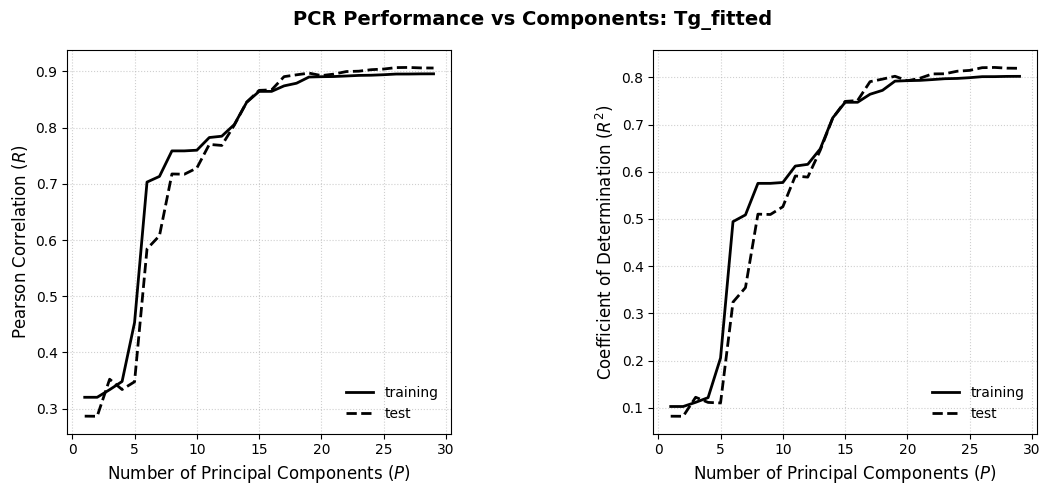

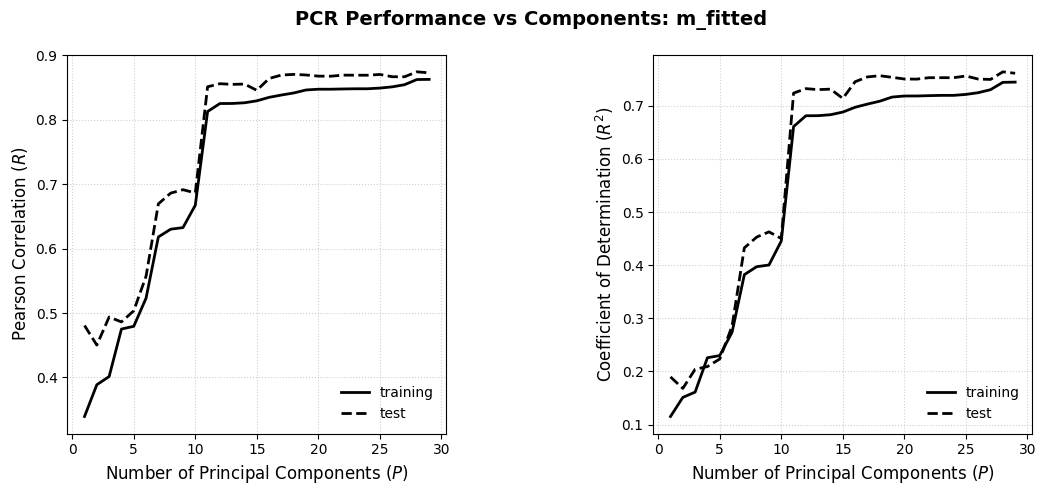

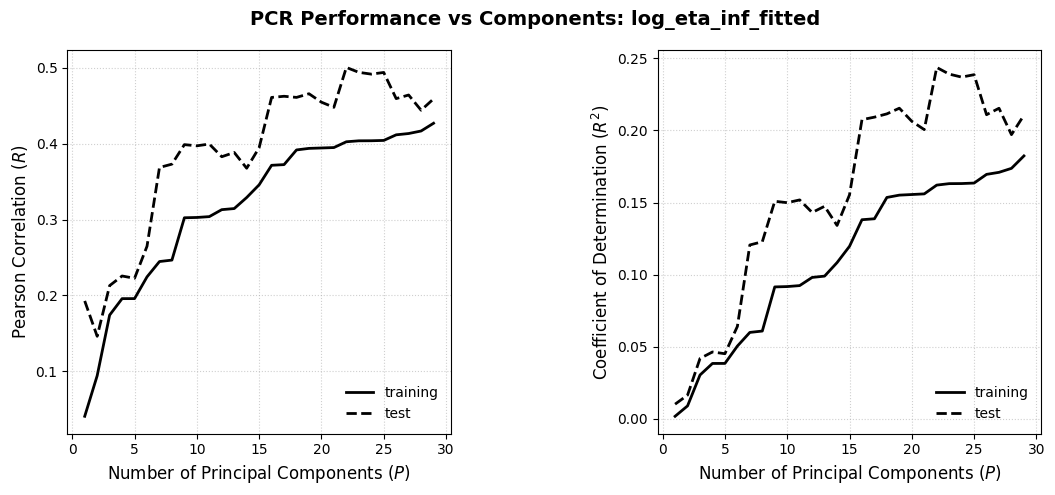

In [10]:
p_spectrum = np.arange(1, 30, 1) # [1, 3, 5, 7, ..., 99]

pcr_metrics = compute_pcr_components_metrics(
    X_train_scaled,
    y_train_scaled,
    X_test_scaled,
    y_test_scaled,
    p_array=p_spectrum
)

pcr_plots_path = plots_path / "pcr_performance_plots"
pcr_plots_path.mkdir(parents=True, exist_ok=True)

for target in pcr_metrics.keys():
    fig_pcr = plot_pcr_performance(pcr_metrics[target], target_name=target)
    fig_pcr.savefig(pcr_plots_path / f"{target}_PCR_Performance.pdf", bbox_inches='tight')

[INFO] 2026-09-24 11:54:42 - Extracting robust features using CustomPCR over 100 splits.
[INFO] 2026-09-24 11:55:08 - Rendering sorted raw feature importance S-curves for 3 targets.


,feature,original_index,weight,std,abs_weight
0,W_Max_SpaceGroupNumber,550,-0.042706,0.004230,0.042706
1,W_Sum_ElectronAffinity,354,-0.037882,0.004358,0.037882
2,A_Max_FusionEnthalpy,375,-0.036354,0.005359,0.036354
3,W_Std_SpaceGroupNumber,553,-0.035870,0.003840,0.035870
4,W_Max_num_oxistates,340,-0.035081,0.004791,0.035081
5,W_Sum_num_oxistates,344,-0.034383,0.003960,0.034383
6,W_Sum_SpaceGroupNumber,554,-0.032269,0.004729,0.032269
7,W_Max_FusionEnthalpy,370,-0.030456,0.003341,0.030456
8,A_Std_FusionEnthalpy,378,-0.030093,0.004868,0.030093
9,A_Mean_SpaceGroupNumber,557,-0.029742,0.004230,0.029742


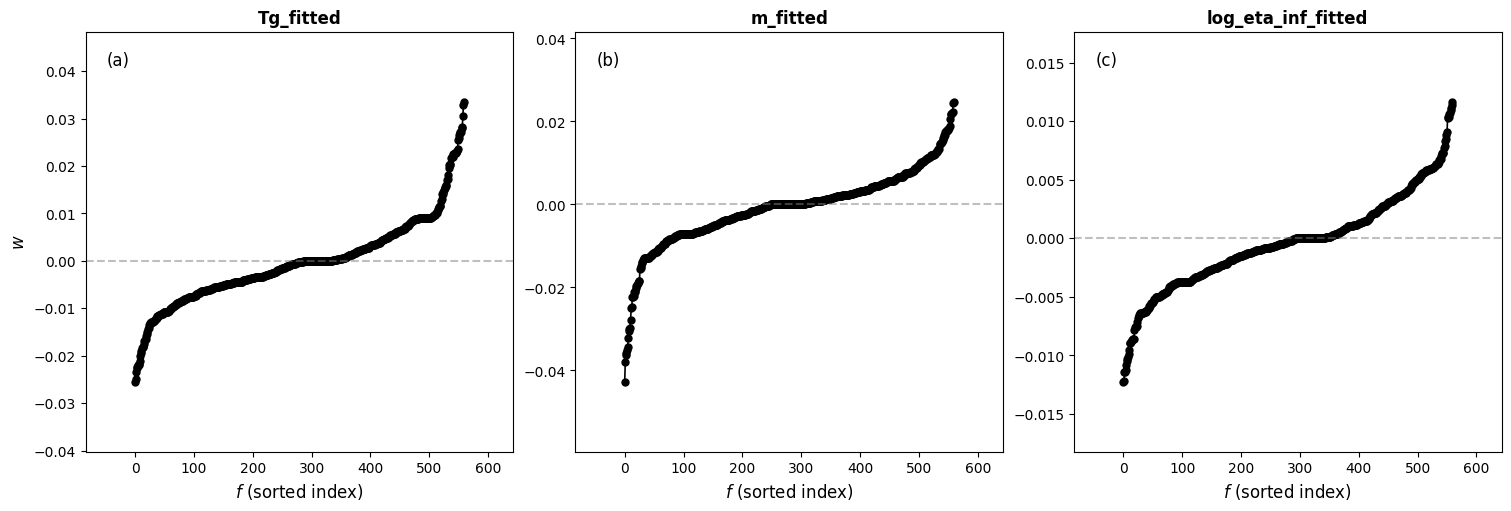

In [11]:
# Feature weights plots (ordered)
pcr_base_model = CustomPCR(n_components=15, fit_intercept=True)
importance_data = extract_importance(
    X=X_train_scaled,
    y=y_train_scaled,
    base_model=pcr_base_model,
    n_splits=100,
    sort_by='magnitude' # <- Ordina per il peso più forte, a prescindere dal segno
)

fig_importance = plot_sorted_feature_importance(importance_data, top_n=0)
fig_importance.savefig(plots_path / 'features_importance_pcr.pdf', bbox_inches='tight')


importance_data['m_fitted'].head(20) # log_eta_inf
# print("\nTop 10 features per Tg_fitted:")
# print(importance_data['Tg_fitted'].head(10)[['original_index', 'feature', 'weight', 'abs_weight']])

In [12]:
pcr_representatives = extract_pc_representatives(
    X_train_scaled,
    y_train_scaled,
    n_components=15
)

print("Top Principal Components for Tg (Sorted by Importance):")
display(pcr_representatives['m_fitted'].head(20))

Top Principal Components for Tg (Sorted by Importance):


,Component,Regression_Weight,Abs_Weight,Explained_Variance_%,Top_Representative_Feature,Feature_Loading
0,PC11,-0.162468,0.162468,1.588184,A_Max_FusionEnthalpy,0.193919
1,PC7,0.087220,0.087220,2.774911,A_Mean_NdUnfilled,0.135349
2,PC10,0.068640,0.068640,1.864237,W_Std_GSvolume_pa,0.126828
3,PC12,-0.055430,0.055430,1.285443,A_Mean_GSmagmom,0.219645
4,PC6,-0.046132,0.046132,4.006467,A_Std_zeff,0.125635
5,PC4,-0.038546,0.038546,8.466933,W_Std_NsValence,0.107489
6,PC15,-0.035098,0.035098,0.787602,W_Std_NValence,0.159466
7,PC8,-0.033798,0.033798,2.550445,A_Min_mass_number,0.138605
8,PC1,0.028224,0.028224,28.127557,W_Mean_zeff,0.079886
9,PC2,0.020289,0.020289,16.977804,A_Mean_atomic_number,0.089232


[INFO] 2026-09-24 11:55:09 - Rendering sorted PC importance S-curves for 3 targets.


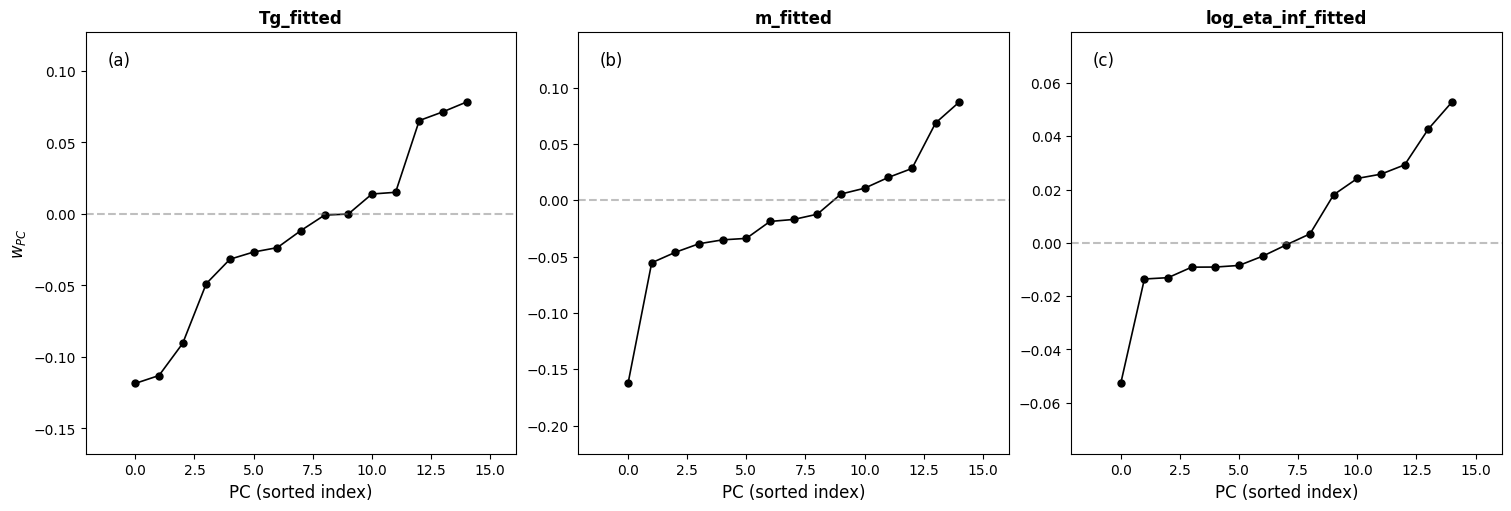

In [13]:
# # Top PC analysis

# Se hai 500 features, puoi estrarre tutte le componenti o un numero sufficientemente alto
# per vedere l'intera S-curve della PCR
pcr_representatives_full = extract_pc_representatives(
    X_train_scaled, 
    y_train_scaled, 
    n_components=15 # Regola questo numero in base a quante PC vuoi plottare
)

# Plot S-Curve senza annotazioni, come da tua richiesta
fig_pcr_importance = plot_sorted_pc_importance(
    pc_dict=pcr_representatives_full, 
    top_n=0
)

fig_pcr_importance.savefig(pcr_plots_path / "PCR_S_Curve_Importance.pdf", bbox_inches='tight')

In [14]:
# Training model

pcr_model = CustomPCR(n_components=15, fit_intercept=True)
pcr_model.fit(X_train_scaled, y_train_scaled)

pickle.dump(pcr_model, open(model_path / "pcr_model.pkl", 'wb'))

logger.info("Model successfully trained and saved!")

[INFO] 2026-09-24 11:55:10 - Model successfully trained and saved!


In [15]:
# Evaluating model

target_columns = ['Tg', 'm','log_eta_inf']

evaluation_metrics = evaluate_final_model(
    model=pcr_model,
    X_test=X_test_scaled,
    y_test=y_test_scaled,
    viscosity_df=raw_data,
    target_cols=target_columns,
    y_scaler=y_scaler
)

TypeError: evaluate_final_model() missing 2 required positional arguments: 'X_train' and 'y_train'

[INFO] 2026-09-22 16:10:49 - Rendering 2D density correlation plot with residual inset.


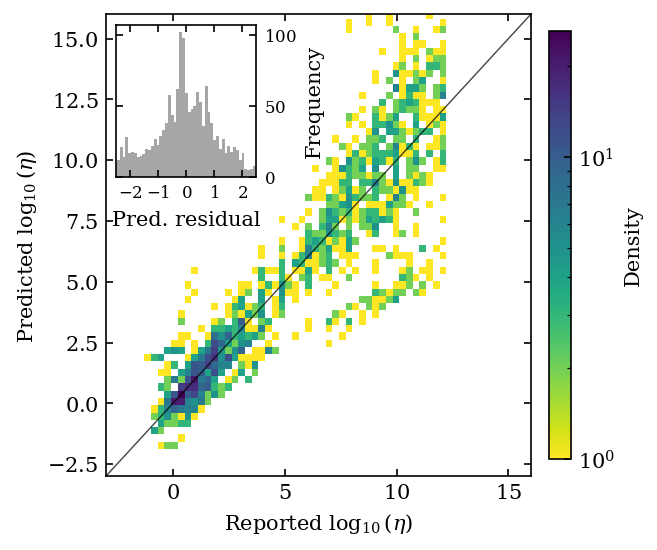

In [ ]:
# Cassar density plot

y_true_visc = evaluation_metrics["viscosity_arrays"]["true_experimental"]
y_pred_visc = evaluation_metrics["viscosity_arrays"]["predicted_myega"]

fig_density = plot_viscosity_density_correlation(
    y_true=y_true_visc, 
    y_pred=y_pred_visc
)

fig_density.savefig(plots_path / '2D_density_histogram.pdf', bbox_inches='tight')
fig_density.savefig(plots_path / '2D_density_histogram.png', bbox_inches='tight')

[INFO] 2026-09-22 16:10:51 - Extracting distance and RMSE metrics into a DataFrame.


,ID,Name,Distance,RMSE
0,709,1Al₂O₃.50P₂O₅.18SrO.31ZnO,2.010101,6.250161
1,201,50Na₂O.50P₂O₅,0.100251,4.859152
2,141,50B₂O₃.50ZnO,2.000000,4.795713
3,806,51Li₂O.49P₂O₅,1.196148,4.605613
4,265,15Al₂O₃.65B₂O₃.20CaO,0.151111,3.883941
5,233,7Al₂O₃.11BeO.3K₂O.4Na₂O.76SiO₂,1.227778,3.870952
6,220,74B₂O₃.16BaO.10La₂O₃,1.110106,3.673531
7,483,13BaO.27Na₂O.60SiO₂,0.109890,3.516294
8,428,15Na₂O.27PbO.58SiO₂,0.095810,3.218046
9,18,50Na₂O.50SiO₂,0.161031,3.118796


[INFO] 2026-09-22 16:10:51 - Rendering square scatter plot for Extrapolation Distance vs RMSE.


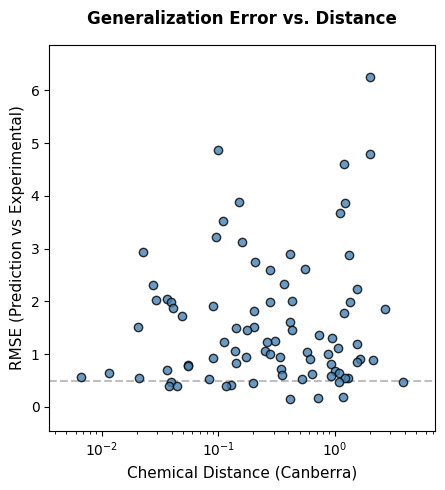

In [ ]:
# Test glasses vs performance analysis

# Get glass names
compounds = raw_data.columns[:-3].tolist()
glass_names_dict = generate_glass_names(raw_data, compounds)

# Get model prediction
y_pred_scaled  = pcr_model.predict(X_test_scaled)
y_pred_physical = y_scaler.inverse_transform(y_pred_scaled)

target_columns = ['Tg', 'm','log_inf']

# Prediction dataframe
predictions_df = pd.DataFrame(
    y_pred_physical,
    columns=target_columns,
    index=y_test.index
)

# Generating distance data
metrics_df = generate_extrapolation_metrics(
    compounds=compounds,
    viscosity_df=raw_data,
    predictions_df=predictions_df, 
    names_dict=glass_names_dict
)
display(metrics_df.head(10))

# Generating distance plot
fig_distance = plot_rmse_vs_distance_square(metrics_df)
fig_distance.savefig(plots_path / 'distance_plot.pdf', bbox_inches='tight')

[INFO] 2026-09-22 16:10:51 - Training ensemble of 100 bootstrap models...
[INFO] 2026-09-22 16:11:31 - Rendering bootstrap prediction grids for 85 glasses.


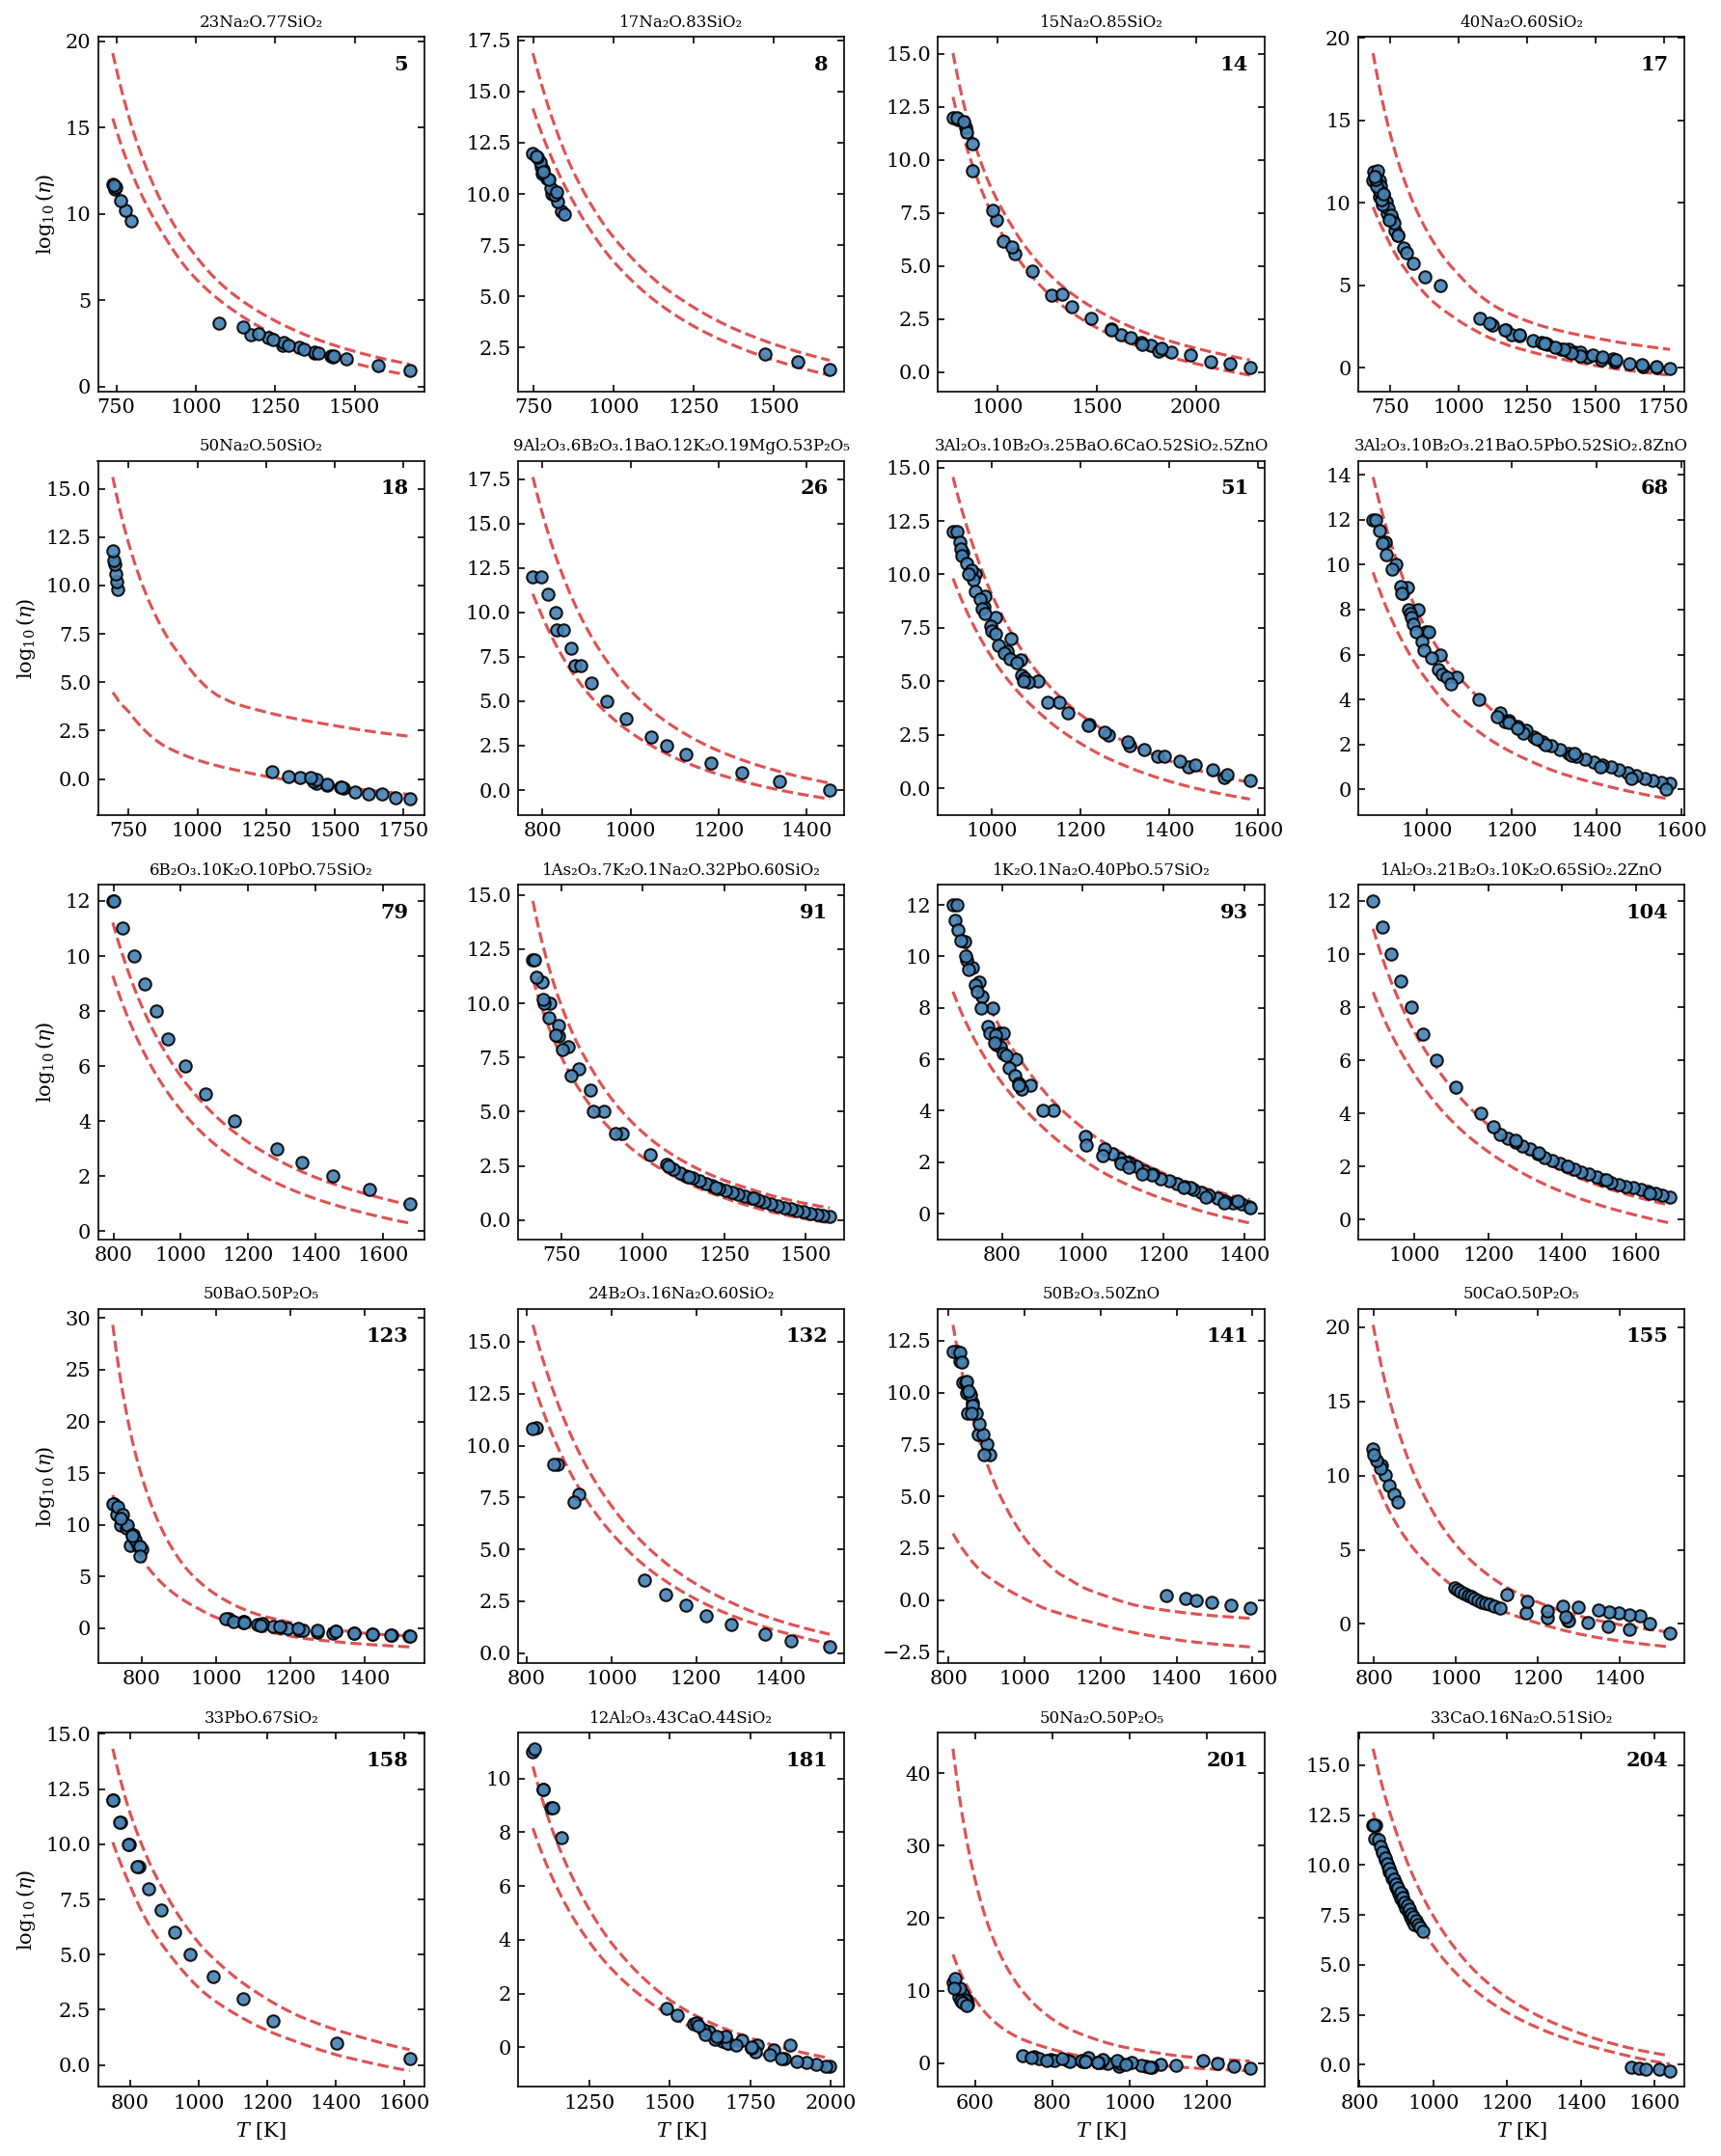

In [ ]:
# Plotting test liquids viscosities with uncertainty bars

pcr_base_model = CustomPCR(n_components=15, fit_intercept=True)

predictions_df, distributions_dict = generate_bootstrap_predictions(
    base_model=pcr_base_model,
    X_train=X_train_scaled,
    y_train=y_train_scaled,
    X_test=X_test_scaled,
    y_scaler=y_scaler,
    n_estimators=100
)

viscosity_plots_path = plots_path / "test_viscosity_plots"
viscosity_plots_path.mkdir(parents=True, exist_ok=True)

plot_viscosity_grids_bootstrap(
    viscosity_df=raw_data,
    distributions_dict=distributions_dict,
    names_dict=glass_names_dict,
    save_dir=viscosity_plots_path,
    confidence=95.0
)